# IRFZ44N MOSFET Electrical Loss Model

This notebook contains the final electrical-loss workflow for the 24 V to 12 V buck-converter MOSFET model.

It documents:

- the frozen converter and MOSFET inputs,
- analytical conduction and switching losses,
- LTspice waveform-based validation,
- the 5 A, 10 A and 20 A operating-point comparison,
- electrical sensitivity to switching-transition time, and
- the resulting uncertainty in loss, estimated junction temperature and MOSFET-loss-based efficiency.

Two Rds(on) values are intentionally retained:

- **0.0139 ohm** for direct analytical comparison with the LTspice MOSFET model.
- **0.0175 ohm** as the conservative datasheet maximum at 25°C for sensitivity and electro-thermal work.


## 1. Frozen Electrical Inputs

| Parameter | Value |
|---|---:|
| Input voltage, Vin | 24 V |
| Output voltage, Vout | 12 V |
| Switching frequency | 50 kHz |
| Duty cycle | 0.5 |
| MOSFET | IRFZ44N |
| Gate drive | 10 V |
| Rise time | 60 ns |
| Fall time | 45 ns |
| LTspice-matched Rds(on) | 0.0139 ohm |
| Datasheet maximum Rds(on) at 25°C | 0.0175 ohm |
| Electrical operating points | 5 A, 10 A, 20 A |


In [1]:
# Buck converter operating conditions

Vin = 24.0          # Input voltage, V
Vout = 12.0         # Output voltage, V
Iout = 10.0         # Output current, A
fsw = 50_000        # Switching frequency, Hz
Vgs = 10.0          # Gate-source drive voltage, V

D = Vout / Vin      # Ideal buck-converter duty ratio

print(f"Duty ratio = {D:.3f}")

Duty ratio = 0.500


## MOSFET parameters

**MOSFET On-Resistance Cases**

Two on-resistance values are considered in the analytical calculation.

- **0.0139 ohm** is used as the LTspice-model baseline value. This case provides the most consistent comparison with the LTspice average power result.
- **0.0175 ohm** is the maximum datasheet on-resistance specified at 25°C. This case provides a more conservative analytical estimate.

Changing Rds(on) affects the conduction loss only. The switching loss remains unchanged because the switching-loss equation depends on voltage, current, switching times and switching frequency rather than on-resistance.

The rise and fall times are taken from the manufacturer datasheet and
are used to estimate switching loss.

In [2]:
# IRFZ44N MOSFET parameters

Rds_on_model = 0.0139      # LTspice-model baseline resistance, ohms
Rds_on_datasheet = 0.0175  # Datasheet maximum at 25°C, ohms

tr = 60e-9                 # Datasheet rise time, seconds
tf = 45e-9                 # Datasheet fall time, seconds

## 2. Baseline Analytical Loss Calculation

The analytical model separates MOSFET loss into:

**Conduction loss**

`Pcond = I² × Rds(on) × D`

**Switching loss**

`Psw = 0.5 × Vin × I × (tr + tf) × fs`

The baseline 10 A calculation is evaluated using both Rds(on) assumptions so that the LTspice-matched and conservative datasheet cases remain clearly separated.


In [3]:
import math
import pandas as pd

# MOSFET RMS current
I_mosfet_rms = Iout * math.sqrt(D)

# Conduction loss for both resistance values
P_cond_model = I_mosfet_rms**2 * Rds_on_model
P_cond_datasheet = I_mosfet_rms**2 * Rds_on_datasheet

# Switching loss is unchanged by Rds(on)
P_sw = 0.5 * Vin * Iout * (tr + tf) * fsw

# Total losses
P_total_model = P_cond_model + P_sw
P_total_datasheet = P_cond_datasheet + P_sw

results = pd.DataFrame({
    "Case": [
        "LTspice-model resistance",
        "Datasheet maximum resistance"
    ],
    "Rds(on) (ohm)": [
        Rds_on_model,
        Rds_on_datasheet
    ],
    "Conduction loss (W)": [
        P_cond_model,
        P_cond_datasheet
    ],
    "Switching loss (W)": [
        P_sw,
        P_sw
    ],
    "Total analytical loss (W)": [
        P_total_model,
        P_total_datasheet
    ]
})

results.round(3)

,Case,Rds(on) (ohm),Conduction loss (W),Switching loss (W),Total analytical loss (W)
0,LTspice-model resistance,0.014,0.695,0.63,1.325
1,Datasheet maximum resistance,0.018,0.875,0.63,1.505


## 3. LTspice Waveform Validation

The following cells import the exported LTspice MOSFET waveforms and calculate instantaneous MOSFET power from VDS and ID over the final 1 ms available in the exported steady-state waveform.

The exported file 'Exported_vds_Id_steady_state.txt' must be available at the path used below when this notebook is rerun.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv(
    "Exported_vds_Id_steady_state.txt",
    sep=r"\s+",
    engine="python"
)

print(data.head())
print(data.columns)

           time    V(Vin,Vsw)        Id(M1)
0  0.000000e+00  0.000000e+00  1.253150e-09
1  2.000000e-14  5.417492e-09  1.856440e-06
2  4.000000e-14  1.088395e-08  3.706178e-06
3  8.000000e-14  2.191459e-08  7.392287e-06
4  1.600000e-13  4.455971e-08  1.468470e-05
Index(['time', 'V(Vin,Vsw)', 'Id(M1)'], dtype='object')


In [6]:
# Use the final 1 ms of the exported waveform
end_time = data["time"].max()
start_time = end_time - 0.001

steady_state = data[
    (data["time"] >= start_time) &
    (data["time"] <= end_time)
].copy()

print(f"Start time: {start_time * 1000:.3f} ms")
print(f"End time: {end_time * 1000:.3f} ms")
print(f"Number of points: {len(steady_state)}")

Start time: 1.440 ms
End time: 2.440 ms
Number of points: 501861


In [7]:
# Convert the steady-state columns to numeric values
steady_state["time"] = pd.to_numeric(
    steady_state["time"],
    errors="coerce"
)

steady_state["V(Vin,Vsw)"] = pd.to_numeric(
    steady_state["V(Vin,Vsw)"],
    errors="coerce"
)

steady_state["Id(M1)"] = pd.to_numeric(
    steady_state["Id(M1)"],
    errors="coerce"
)

# Remove any rows that could not be converted
steady_state = steady_state.dropna(
    subset=["time", "V(Vin,Vsw)", "Id(M1)"]
).copy()

time = steady_state["time"].to_numpy(dtype=float)
vds = steady_state["V(Vin,Vsw)"].to_numpy(dtype=float)
ids = steady_state["Id(M1)"].to_numpy(dtype=float)

# Instantaneous MOSFET power
power = vds * ids

# Average MOSFET power
average_power = np.trapezoid(power, time) / (
    time[-1] - time[0]
)

print(f"Number of valid points = {len(time)}")
print(f"Average MOSFET power from exported data (used Rds(on)=0.0139) = {average_power:.4f} W")

Number of valid points = 501860
Average MOSFET power from exported data (used Rds(on)=0.0139) = 0.7308 W


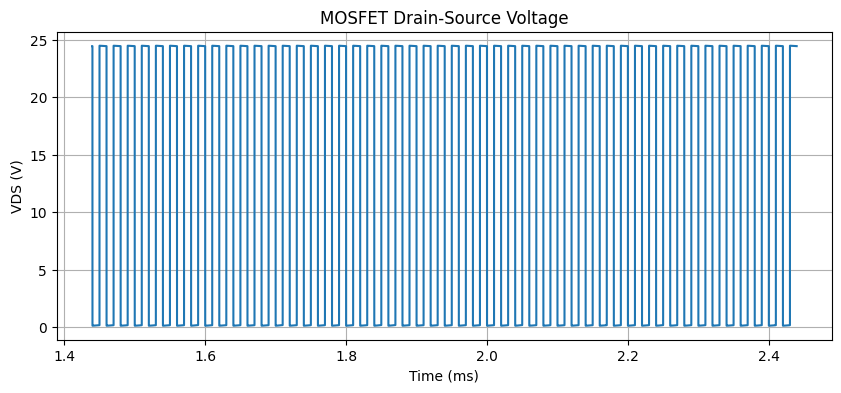

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(time * 1000, vds)
plt.xlabel("Time (ms)")
plt.ylabel("VDS (V)")
plt.title("MOSFET Drain-Source Voltage")
plt.grid()
plt.show()

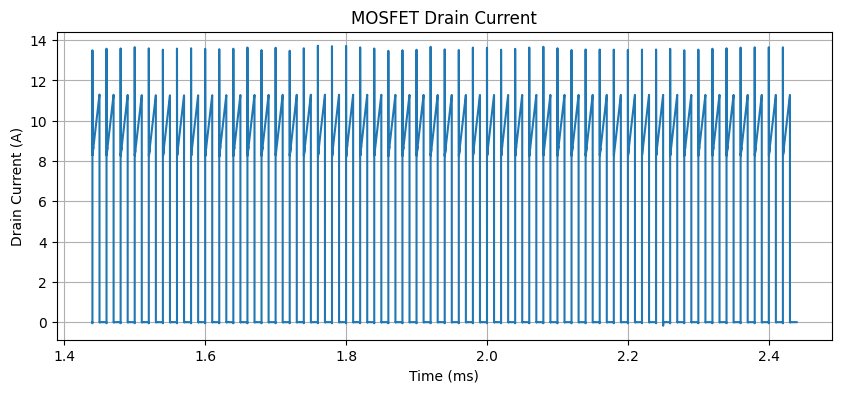

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(time * 1000, ids)
plt.xlabel("Time (ms)")
plt.ylabel("Drain Current (A)")
plt.title("MOSFET Drain Current")
plt.grid()
plt.show()

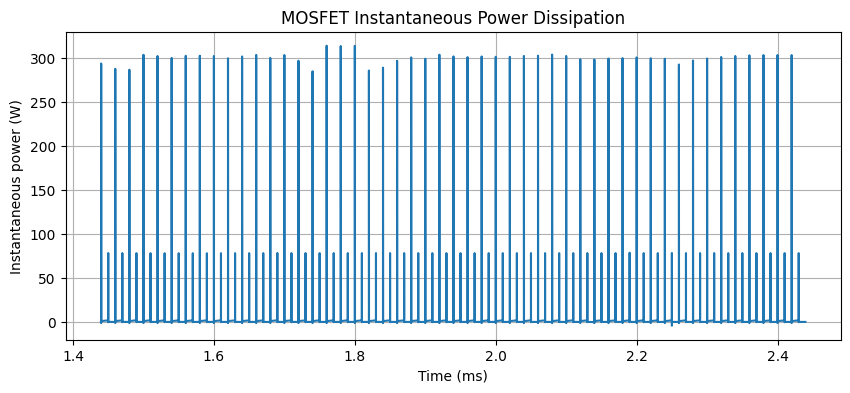

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(time * 1000, power)

plt.xlabel("Time (ms)")
plt.ylabel("Instantaneous power (W)")
plt.title("MOSFET Instantaneous Power Dissipation")
plt.grid()

plt.show()

## 3.1 Separation of LTspice Conduction and Switching Loss

The total LTspice MOSFET loss is separated into approximate conduction and switching components to identify the source of the difference between the analytical and simulated results.

During normal MOSFET conduction, the drain-source voltage is very small. A threshold of **VDS < 1 V** is therefore used to identify the low-voltage on-state region.

The waveform-based conduction contribution is calculated by integrating instantaneous MOSFET power only while `VDS < 1 V`.

The remaining average power is treated as the switching/off-state contribution:

`P_switching,LTspice ≈ P_total,LTspice - P_conduction,LTspice`

Off-state leakage is negligible in this simulation, so this residual is dominated by switching-transition loss.

Because the voltage threshold is a modelling choice, its sensitivity is also checked using 0.5 V, 1 V and 2 V thresholds.

In [11]:
# LTspice loss-component separation

duration = time[-1] - time[0]

vds_threshold = 1.0  # V

# Power dissipated while MOSFET is in its low-VDS conducting state
conduction_power_waveform = np.where(
    vds < vds_threshold,
    power,
    0.0
)

ltspice_conduction_loss = (
    np.trapezoid(conduction_power_waveform, time) / duration
)

# Remaining power is dominated by switching transitions
ltspice_switching_loss = (
    average_power - ltspice_conduction_loss
)

print(f"LTspice total loss       = {average_power:.4f} W")
print(f"LTspice conduction loss  = {ltspice_conduction_loss:.4f} W")
print(f"LTspice switching loss   = {ltspice_switching_loss:.4f} W")

LTspice total loss       = 0.7308 W
LTspice conduction loss  = 0.6671 W
LTspice switching loss   = 0.0636 W


In [12]:
threshold_results = []

for threshold in [0.5, 1.0, 2.0]:

    conduction_component = np.where(
        vds < threshold,
        power,
        0.0
    )

    p_cond = (
        np.trapezoid(conduction_component, time)
        / duration
    )

    p_switch = average_power - p_cond

    threshold_results.append({
        "VDS threshold (V)": threshold,
        "LTspice conduction loss (W)": p_cond,
        "LTspice switching residual (W)": p_switch
    })

threshold_table = pd.DataFrame(threshold_results)

threshold_table.round(4)

,VDS threshold (V),LTspice conduction loss (W),LTspice switching residual (W)
0,0.5,0.6664,0.0644
1,1.0,0.6671,0.0636
2,2.0,0.6685,0.0623


In [13]:
analytical_conduction = 0.695
analytical_switching = 0.630
analytical_total = 1.325

validation_breakdown = pd.DataFrame({
    "Loss component": [
        "Conduction",
        "Switching",
        "Total"
    ],
    "Analytical (W)": [
        analytical_conduction,
        analytical_switching,
        analytical_total
    ],
    "LTspice waveform (W)": [
        ltspice_conduction_loss,
        ltspice_switching_loss,
        average_power
    ]
})

validation_breakdown["Difference (%)"] = (
    abs(
        validation_breakdown["Analytical (W)"]
        - validation_breakdown["LTspice waveform (W)"]
    )
    / validation_breakdown["Analytical (W)"]
    * 100
)

validation_breakdown.round(4)

,Loss component,Analytical (W),LTspice waveform (W),Difference (%)
0,Conduction,0.695,0.6671,4.0090
1,Switching,0.630,0.0636,89.9009
2,Total,1.325,0.7308,44.8482


In [14]:
# Estimate VDS 10%-90% transition durations from the LTspice waveform

Vin_nominal = 24.0

v_low = 0.1 * Vin_nominal
v_high = 0.9 * Vin_nominal
v_mid = 0.5 * Vin_nominal

above_mid = vds > v_mid

crossing_indices = (
    np.where(above_mid[1:] != above_mid[:-1])[0] + 1
)

falling_times = []
rising_times = []

for idx in crossing_indices:

    crossing_time = time[idx]

    # Inspect a short window around each transition
    start_idx = np.searchsorted(
        time,
        crossing_time - 0.5e-6
    )

    end_idx = np.searchsorted(
        time,
        crossing_time + 0.5e-6
    )

    t_window = time[start_idx:end_idx]
    v_window = vds[start_idx:end_idx]

    # VDS falling: MOSFET turning on
    if v_window[0] > v_window[-1]:

        high_cross = np.where(v_window <= v_high)[0]
        low_cross = np.where(v_window <= v_low)[0]

        if len(high_cross) > 0 and len(low_cross) > 0:

            i_high = high_cross[0]

            later_low = low_cross[
                low_cross >= i_high
            ]

            if len(later_low) > 0:

                i_low = later_low[0]

                falling_times.append(
                    t_window[i_low] - t_window[i_high]
                )

    # VDS rising: MOSFET turning off
    else:

        low_cross = np.where(v_window >= v_low)[0]
        high_cross = np.where(v_window >= v_high)[0]

        if len(low_cross) > 0 and len(high_cross) > 0:

            i_low = low_cross[0]

            later_high = high_cross[
                high_cross >= i_low
            ]

            if len(later_high) > 0:

                i_high = later_high[0]

                rising_times.append(
                    t_window[i_high] - t_window[i_low]
                )

mean_vds_fall_ns = np.mean(falling_times) * 1e9
mean_vds_rise_ns = np.mean(rising_times) * 1e9

print(
    f"Mean VDS 90%-10% falling transition = "
    f"{mean_vds_fall_ns:.2f} ns"
)

print(
    f"Mean VDS 10%-90% rising transition = "
    f"{mean_vds_rise_ns:.2f} ns"
)

print(
    f"Combined observed VDS transition duration = "
    f"{mean_vds_fall_ns + mean_vds_rise_ns:.2f} ns"
)

Mean VDS 90%-10% falling transition = 5.74 ns
Mean VDS 10%-90% rising transition = 3.54 ns
Combined observed VDS transition duration = 9.28 ns


## Comparison with LTspice

The direct analytical-to-LTspice comparison uses **Rds(on) = 0.0139 ohm**, matching the baseline resistance associated with the LTspice model.

Using this value gives an analytical total MOSFET loss of **1.325 W**, which is compared with the LTspice average power loss of **0.7308 W**.

The separate **0.0175 ohm datasheet maximum case** is treated as a conservative calculation and is not used in this direct comparison.

In [15]:
# Direct comparison using the LTspice-model baseline Rds(on)
Rds_on_comparison = 0.0139

analytical_power_model_case = 1.325
ltspice_power = 0.7308

difference = analytical_power_model_case - ltspice_power

percentage_difference = (
    abs(difference) / analytical_power_model_case * 100
)

print(f"Rds(on) used for analytical comparison = {Rds_on_comparison:.4f} ohm")
print(f"Analytical power loss using 0.0139 ohm = {analytical_power_model_case:.3f} W")
print(f"LTspice average power loss = {ltspice_power:.3f} W")
print(f"Difference = {abs(difference):.3f} W")
print(f"Percentage difference = {percentage_difference:.1f}%")

Rds(on) used for analytical comparison = 0.0139 ohm
Analytical power loss using 0.0139 ohm = 1.325 W
LTspice average power loss = 0.731 W
Difference = 0.594 W
Percentage difference = 44.8%


### Electrical Validation Result

The waveform decomposition shows that the large difference between the analytical and LTspice total MOSFET loss originates primarily from the simplified switching-loss estimate rather than from the conduction-loss model.

At the 10 A baseline condition:

- Analytical conduction loss = **0.695 W**
- LTspice waveform conduction loss ≈ **0.667 W**
- Difference ≈ **4%**

This indicates close agreement for the conduction-loss model.

In contrast:

- Analytical switching loss = **0.630 W**
- LTspice switching contribution ≈ **0.064 W**

The simplified analytical switching-loss equation therefore substantially overpredicts the switching contribution for the simulated circuit.

The analytical equation uses datasheet rise and fall times totalling **105 ns**, whereas the LTspice waveform shows VDS transitions of only approximately **5.7 ns during turn-on** and **3.5 ns during turn-off** under the ideal gate-drive conditions used in the simulation.

The LTspice result is approximately **44.8% lower than the analytical estimate**, when the difference is normalised to the analytical value.

The comparison therefore validates the conduction-loss calculation reasonably well while identifying switching-transition modelling as the dominant source of uncertainty in the simplified analytical model.

The conservative datasheet-based loss model is retained for the thermal study rather than replacing it with the lower LTspice value, because the ideal LTspice gate source does not represent all practical gate-drive and parasitic effects.

## 4. Three Electrical Operating Points: 5 A, 10 A and 20 A

The direct analytical-to-LTspice comparison uses **Rds(on) = 0.0139 ohm** because it more closely matches the resistance represented by the LTspice MOSFET model.

The datasheet maximum value of **0.0175 ohm** is reserved for conservative thermal and electro-thermal analysis.

**LTspice run provenance:** the 5 A, 10 A and 20 A values were recorded from the same LTspice schematic by changing only the resistive load. At 12 V output, the corresponding load resistances are **2.4 ohm, 1.2 ohm and 0.6 ohm**. The committed `.asc` preserves the 10 A / 1.2 ohm baseline; separate 5 A and 20 A schematic copies were not retained. See `../LTspice_run_notes.md`.


In [16]:
import pandas as pd

# Fixed converter and MOSFET parameters
Vds = 24
Rds_on_model = 0.0139
duty_cycle = 0.5
rise_time = 60e-9
fall_time = 45e-9
switching_frequency = 50e3

# Three load currents
load_currents = [5, 10, 20]

results = []

for current in load_currents:
    conduction_loss = current**2 * Rds_on_model * duty_cycle

    switching_loss = (
        0.5
        * Vds
        * current
        * (rise_time + fall_time)
        * switching_frequency
    )

    total_loss = conduction_loss + switching_loss

    results.append({
        "Load current (A)": current,
        "Conduction loss (W)": conduction_loss,
        "Switching loss (W)": switching_loss,
        "Analytical total loss (W)": total_loss
    })

analytical_results = pd.DataFrame(results)

analytical_results

,Load current (A),Conduction loss (W),Switching loss (W),Analytical total loss (W)
0,5,0.17375,0.315,0.48875
1,10,0.69500,0.630,1.32500
2,20,2.78000,1.260,4.04000


In [17]:

ltspice_losses = [
    0.221,   # 5 A result
    0.731,   # 10 A result
    2.744    # 20 A result
]

analytical_results["LTspice loss (W)"] = ltspice_losses

analytical_results["Difference (W)"] = (
    analytical_results["Analytical total loss (W)"]
    - analytical_results["LTspice loss (W)"]
)

analytical_results["Difference (%)"] = (
    analytical_results["Difference (W)"]
    / analytical_results["Analytical total loss (W)"]
    * 100
)

analytical_results.round(3)

,Load current (A),Conduction loss (W),Switching loss (W),Analytical total loss (W),LTspice loss (W),Difference (W),Difference (%)
0,5,0.174,0.315,0.489,0.221,0.268,54.783
1,10,0.695,0.630,1.325,0.731,0.594,44.830
2,20,2.780,1.260,4.040,2.744,1.296,32.079


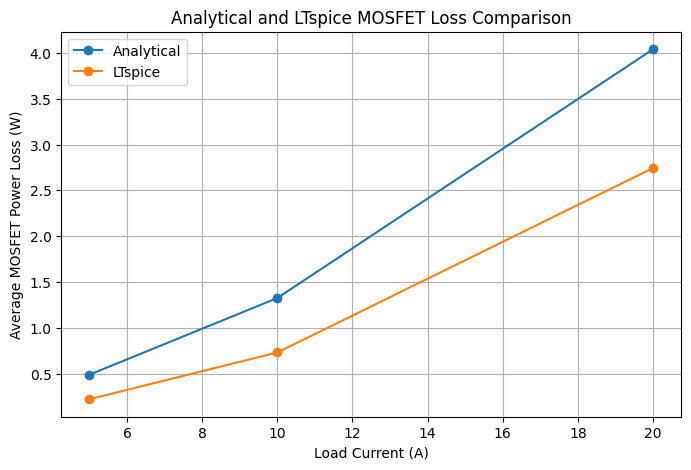

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    analytical_results["Load current (A)"],
    analytical_results["Analytical total loss (W)"],
    marker="o",
    label="Analytical"
)

plt.plot(
    analytical_results["Load current (A)"],
    analytical_results["LTspice loss (W)"],
    marker="o",
    label="LTspice"
)

plt.xlabel("Load Current (A)")
plt.ylabel("Average MOSFET Power Loss (W)")
plt.title("Analytical and LTspice MOSFET Loss Comparison")
plt.grid()
plt.legend()
plt.show()

## Conclusion

The MOSFET loss was evaluated at load currents of **5 A, 10 A and 20 A** using analytical calculations and LTspice. The analytical comparison used the LTspice-model baseline resistance of **0.0139 ohm**.

An acceptance limit of 10% was selected. Since all three load-point differences exceed this limit, the disagreement was investigated and documented.

Both methods showed that MOSFET power loss increased as load current increased. This occurs because conduction loss increases approximately with the square of current, while switching loss increases approximately in proportion to current.

The analytical calculation predicted higher losses than LTspice at all three load points. The percentage difference decreased from approximately **54.8% at 5 A** to **32.1% at 20 A**. The difference is mainly caused by the simplified analytical switching-loss equation, which assumes linear voltage-current overlap over the full datasheet rise and fall times. LTspice instead calculates power directly from the simulated voltage and current waveforms.

The waveform decomposition confirms that the conduction-loss estimate agrees closely with LTspice at the 10 A baseline case, while the simplified datasheet-transition switching model is the dominant source of the total-loss discrepancy.

The results confirm that load current has a significant effect on MOSFET heat generation, particularly at the high-load operating point.

## 5. Electrical Loss Table Export

The analytical and LTspice results for the 5 A, 10 A and 20 A operating points are assembled into a compact table for reuse by the thermal and engineering-assessment stages.

In [19]:
# Create the electrical loss table

electrical_loss_table = analytical_results[
    [
        "Load current (A)",
        "Conduction loss (W)",
        "Switching loss (W)",
        "Analytical total loss (W)",
        "LTspice loss (W)"
    ]
].copy()

# Add case names
electrical_loss_table.insert(
    0,
    "Case",
    ["Low load", "Baseline", "High load"]
)

# Add fixed operating-point information
electrical_loss_table.insert(1, "Input voltage (V)", 24.0)
electrical_loss_table.insert(2, "Output voltage (V)", 12.0)
electrical_loss_table.insert(3, "Switching frequency (Hz)", 50000)
electrical_loss_table.insert(4, "Duty cycle", 0.5)

# Resistance used for the direct analytical-to-LTspice comparison
electrical_loss_table["Rds(on) used (ohm)"] = 0.0139

# Initial assumed junction temperature
electrical_loss_table["Assumed junction temperature (°C)"] = 25.0

electrical_loss_table.round(4)

,Case,Input voltage (V),Output voltage (V),Switching frequency (Hz),Duty cycle,Load current (A),Conduction loss (W),Switching loss (W),Analytical total loss (W),LTspice loss (W),Rds(on) used (ohm),Assumed junction temperature (°C)
0,Low load,24.0,12.0,50000,0.5,5,0.1737,0.315,0.4888,0.221,0.0139,25.0
1,Baseline,24.0,12.0,50000,0.5,10,0.6950,0.630,1.3250,0.731,0.0139,25.0
2,High load,24.0,12.0,50000,0.5,20,2.7800,1.260,4.0400,2.744,0.0139,25.0


In [20]:
output_path = "../../data/electrical_loss_table.csv"

electrical_loss_table.to_csv(
    output_path,
    index=False
)

print(f"CSV saved to: {output_path}")

CSV saved to: ../../data/electrical_loss_table.csv


## 6. Electrical Sensitivity Study

The nominal electrical model is tested against plausible switching-transition uncertainty while keeping the conservative **Rds(on) = 0.0175 ohm** fixed.

Three switching cases are used:

- Fast switching: 80% of nominal rise/fall times
- Nominal switching: 60 ns rise, 45 ns fall
- Slow switching: 120% of nominal rise/fall times


In [21]:
import pandas as pd

Vin = 24.0
fs = 50e3
D = 0.5

currents = [5, 10, 20]

Rds_on = 0.0175

switching_cases = {
    "Fast switching": (60e-9 * 0.8, 45e-9 * 0.8),
    "Nominal switching": (60e-9, 45e-9),
    "Slow switching": (60e-9 * 1.2, 45e-9 * 1.2)
}

results = []

for current in currents:

    for case_name, (tr_test, tf_test) in switching_cases.items():

        conduction_loss = current**2 * Rds_on * D

        switching_loss = (
            0.5
            * Vin
            * current
            * (tr_test + tf_test)
            * fs
        )

        total_loss = conduction_loss + switching_loss

        results.append({
            "Current (A)": current,
            "Switching case": case_name,
            "Rise time (ns)": tr_test * 1e9,
            "Fall time (ns)": tf_test * 1e9,
            "Conduction loss (W)": conduction_loss,
            "Switching loss (W)": switching_loss,
            "Total loss (W)": total_loss
        })

week8_sensitivity = pd.DataFrame(results)

week8_sensitivity.round(4)

,Current (A),Switching case,Rise time (ns),Fall time (ns),Conduction loss (W),Switching loss (W),Total loss (W)
0,5,Fast switching,48.0,36.0,0.2188,0.252,0.4708
1,5,Nominal switching,60.0,45.0,0.2188,0.315,0.5338
2,5,Slow switching,72.0,54.0,0.2188,0.378,0.5968
3,10,Fast switching,48.0,36.0,0.8750,0.504,1.3790
4,10,Nominal switching,60.0,45.0,0.8750,0.630,1.5050
5,10,Slow switching,72.0,54.0,0.8750,0.756,1.6310
6,20,Fast switching,48.0,36.0,3.5000,1.008,4.5080
7,20,Nominal switching,60.0,45.0,3.5000,1.260,4.7600
8,20,Slow switching,72.0,54.0,3.5000,1.512,5.0120


### Switching-Time Sensitivity Result

The switching-time sensitivity study shows that increasing the MOSFET rise and fall times increases switching loss because the device spends longer in the switching transition region.

At the nominal switching times of **60 ns rise time** and **45 ns fall time**, the calculated total MOSFET losses are approximately **0.534 W at 5 A**, **1.505 W at 10 A**, and **4.760 W at 20 A**.

Reducing the switching transition times by 20% lowers the predicted total loss, while increasing them by 20% increases the total loss. The absolute effect becomes larger at higher load current because switching loss increases with current.

The overall conclusion remains unchanged across the tested switching-time range: MOSFET power loss increases strongly with load current, and the 20 A operating point remains the most electrically and thermally demanding of the electrically derived cases.

## 7. Effect of Electrical Uncertainty

The switching-time sensitivity results are mapped to the validated aluminium one-pass thermal response to estimate how electrical uncertainty changes:

- total MOSFET loss,
- estimated junction temperature, and
- MOSFET-loss-based efficiency.

These temperatures are one-pass thermal estimates for the uncertainty study; they are not new fully coupled operating points.


In [22]:
import pandas as pd
import numpy as np

# Load validated aluminium one-pass thermal response
thermal_response_al = pd.read_csv(
    "../../data/thermal_response_aluminium.csv"
)

thermal_power_al = thermal_response_al["Heat_input_W"].to_numpy()
thermal_temperature_al = thermal_response_al["Junction_temperature_C"].to_numpy()

# Add zero-power ambient point
thermal_power_al = np.insert(thermal_power_al, 0, 0.0)
thermal_temperature_al = np.insert(thermal_temperature_al, 0, 25.0)

def get_thermal_temperature_aluminium(power_loss):
    return np.interp(
        power_loss,
        thermal_power_al,
        thermal_temperature_al
    )

In [23]:
Vout = 12.0

week8_uncertainty = week8_sensitivity.copy()

# Convert each sensitivity loss into an estimated junction temperature
week8_uncertainty["Estimated Tj (°C)"] = (
    week8_uncertainty["Total loss (W)"]
    .apply(get_thermal_temperature_aluminium)
)

# Output power
week8_uncertainty["Output power (W)"] = (
    Vout * week8_uncertainty["Current (A)"]
)

# Efficiency considering MOSFET loss only
week8_uncertainty["MOSFET efficiency (%)"] = (
    week8_uncertainty["Output power (W)"]
    /
    (
        week8_uncertainty["Output power (W)"]
        + week8_uncertainty["Total loss (W)"]
    )
    * 100
)

week8_uncertainty[
    [
        "Current (A)",
        "Switching case",
        "Total loss (W)",
        "Estimated Tj (°C)",
        "MOSFET efficiency (%)"
    ]
].round(3)

,Current (A),Switching case,Total loss (W),Estimated Tj (°C),MOSFET efficiency (%)
0,5,Fast switching,0.471,27.467,99.222
1,5,Nominal switching,0.534,27.797,99.118
2,5,Slow switching,0.597,28.127,99.015
3,10,Fast switching,1.379,32.225,98.864
4,10,Nominal switching,1.505,32.885,98.761
5,10,Slow switching,1.631,33.545,98.659
6,20,Fast switching,4.508,48.618,98.156
7,20,Nominal switching,4.760,49.938,98.055
8,20,Slow switching,5.012,51.258,97.954


In [24]:
uncertainty_summary = (
    week8_uncertainty
    .groupby("Current (A)")
    .agg(
        Min_loss_W=("Total loss (W)", "min"),
        Max_loss_W=("Total loss (W)", "max"),
        Min_Tj_C=("Estimated Tj (°C)", "min"),
        Max_Tj_C=("Estimated Tj (°C)", "max"),
        Min_efficiency_pct=("MOSFET efficiency (%)", "min"),
        Max_efficiency_pct=("MOSFET efficiency (%)", "max")
    )
    .reset_index()
)

uncertainty_summary["Loss variation (W)"] = (
    uncertainty_summary["Max_loss_W"]
    - uncertainty_summary["Min_loss_W"]
)

uncertainty_summary["Temperature variation (°C)"] = (
    uncertainty_summary["Max_Tj_C"]
    - uncertainty_summary["Min_Tj_C"]
)

uncertainty_summary["Efficiency variation (percentage points)"] = (
    uncertainty_summary["Max_efficiency_pct"]
    - uncertainty_summary["Min_efficiency_pct"]
)

uncertainty_summary.round(3)

,Current (A),Min_loss_W,Max_loss_W,Min_Tj_C,Max_Tj_C,Min_efficiency_pct,Max_efficiency_pct,Loss variation (W),Temperature variation (°C),Efficiency variation (percentage points)
0,5,0.471,0.597,27.467,28.127,99.015,99.222,0.126,0.66,0.206
1,10,1.379,1.631,32.225,33.545,98.659,98.864,0.252,1.32,0.205
2,20,4.508,5.012,48.618,51.258,97.954,98.156,0.504,2.64,0.202


### Interpretation

The switching-time sensitivity study produces a range of possible MOSFET losses, junction temperatures and efficiencies around the nominal operating condition.

The effect becomes larger as load current increases because switching loss increases with current. Therefore, uncertainty in the assumed switching-transition times has a greater absolute effect at the 20 A operating point than at 5 A.

Despite this variation, the overall ranking of the operating points remains unchanged: the 20 A case produces the highest loss and junction temperature, while the 5 A case remains the least demanding.

This indicates that the main electrical conclusions are robust to the tested switching-time uncertainty.

## 8. Final Electrical-Model Note

The electrical model is now frozen around the **5 A, 10 A and 20 A** operating points.

The 0.0139 ohm resistance case is used only for direct LTspice validation, while the 0.0175 ohm datasheet-maximum case is used for conservative thermal and electro-thermal analysis. The final coupled operating results are documented in `../../coupled-simulation/electro_thermal_coupling_cleaned.ipynb`.
